## Phase 0 - Imports & Configuration

In [1]:
!pip install stanza

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 24.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 21.0 MB/s eta 0:00:00


In [2]:
import os
import json
import re
import time
from collections import Counter

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import stanza
from sklearn.metrics import (
    accuracy_score, average_precision_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score,
    precision_recall_curve, precision_score,
    recall_score, roc_auc_score, roc_curve
)
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from tqdm.notebook import tqdm


In [3]:
DATASET_PATH = "/kaggle/input/datasets/venesiaarisaputri/prdect-id-dataset/PRDECT-ID Dataset.csv"
MODEL_DIR    = "/kaggle/working/model_weights"
EVAL_DIR     = "/kaggle/working/evaluation_metrics"
RESULT_DIR   = "/kaggle/working/results"
NB_MODEL_PATH    = os.path.join(MODEL_DIR, "naive_bayes_model.joblib")
TFIDF_MODEL_PATH = os.path.join(MODEL_DIR, "tfidf_naive_bayes_vectorizer.joblib")

os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(EVAL_DIR,   exist_ok=True)
os.makedirs(RESULT_DIR, exist_ok=True)

LABEL2ID = {"negatif": 0, "positif": 1}
ID2LABEL = {0: "negatif", 1: "positif"}

CONFIDENCE_THRESHOLD = 0.75
SIMILARITY_THRESHOLD = 0.99
TOP_N_SUMMARY        = 10
MIN_COUNT            = 3

NB_POS_THRESHOLD = 0.5
NB_NEG_THRESHOLD = -0.5
NB_MIN_FREQ      = 3

TFIDF_MAX_FEATURES  = 20000
TFIDF_NGRAM_RANGE   = (1, 2)
TFIDF_MIN_DF        = 3
TFIDF_SUBLINEAR_TF  = True
TFIDF_STRIP_ACCENTS = "unicode"

NEGATION_WORDS = {"tidak", "bukan", "belum", "jangan", "kurang", "tanpa"}
SPLIT_CONJUNCTIONS = ["tapi", "tetapi", "namun", "meski", "meskipun", "walaupun", "walau", "dan", "serta", "juga", "karena", "soalnya", "sebab", "padahal", "sedangkan"]

REGEX_PATTERNS = [
    (r"(.)\1{2,}",          r"\1\1"),   # "bangeeetttt" -> "bangeett"
    (r"([a-zA-Z])\1\b",     r"\1"),     # "bangett" -> "banget"
    (r"([!?,;.]){2,}",      r"\1"),     # ",,,,," -> ","
    (r"\b(\w+)\s+\1\b",     r"\1"),     # "bagus bagus" -> "bagus"
    (r"\s+([!?,;.])",       r"\1"),     # space before punctuation
    (r"([!?,;.])(?!\s)",    r"\1 "),    # space after punctuation
]

SLANG_DICT = {
    "gak": "tidak", "ga": "tidak", "gk": "tidak", "nggak": "tidak", "ngga": "tidak", "engga": "tidak", "tdk": "tidak", "tak": "tidak",
    "tp": "tapi", "tpi": "tapi", "cuma": "hanya", "cmn": "hanya", "cuman": "hanya",
    "bgt": "banget", "bgd": "banget", "bngt": "banget", "bet": "banget", "bnget": "banget", "sgt": "sangat", "sngat": "sangat", "sangt": "sangat",
    "sy": "saya", "sya": "saya", "gw": "saya", "gue": "saya", "aku": "saya", "ak": "saya", "lo": "kamu", "lu": "kamu", "kmu": "kamu",
    "ud": "sudah", "udh": "sudah", "uda": "sudah", "udah": "sudah", "sdh": "sudah", "blm": "belum", "blum": "belum", "belom": "belum", "blom": "belum",
    "lg": "lagi", "lgi": "lagi", "bs": "bisa", "bsa": "bisa", "skrg": "sekarang", "skr": "sekarang", "skg": "sekarang", "cb": "coba", "cba": "coba",
    "br": "baru", "bru": "baru", "cpt": "cepat", "cepet": "cepat", "cpet": "cepat", "lm": "lama", "lma": "lama", "hrs": "harus", "hrus": "harus",
    "bgs": "bagus", "bgus": "bagus", "mntp": "bagus", "mntap": "bagus", "mantep": "bagus", "mntep": "bagus", "mantap": "bagus",
    "sj": "saja", "aja": "saja", "sja": "saja", "aj": "saja", "doank": "saja", "doang": "saja",
    "bbrp": "beberapa", "bbrapa": "beberapa", "bbrpa": "beberapa", "bebrpa": "beberapa", "brp": "berapa", "brpa": "berapa", "brapa": "berapa",
    "bgini": "seperti ini", "begini": "seperti ini", "sperti": "seperti", "yg": "yang", "yng": "yang", "krn": "karena", "karna": "karena",
    "dgn": "dengan", "dg": "dengan", "dr": "dari", "dri": "dari", "utk": "untuk", "buat": "untuk", "jg": "juga", "sm": "sama", "mk": "maka",
    "brg": "barang", "brng": "barang", "ongkir": "ongkos kirim", "ori": "original", "ok": "oke", "pngiriman": "pengiriman", "pngirim": "pengirim", "krm": "kirim",
    "saller": "penjual", "saler": "penjual", "seler": "penjual", "seller": "penjual", "pnjual": "penjual",
    "lmyn": "lumayan", "lmayan": "lumayan", "kualits": "kualitas", "packing": "packaging",
    "wkwk": "", "wkwkwk": "", "haha": "", "hihi": "", "hehe": "", "masyaallah": "", "sih": "", "alhamdulilah": "alhamdulillah", "alhamdullilah": "alhamdulillah",
    "mantul": "bagus banget", "gokil": "luar biasa", "okesip": "oke siap"
}

STOPWORDS = {
    "yang", "di", "dan", "ini", "itu", "dengan", "untuk", "pada", "adalah", "dari", "dalam", "ke", "akan", "oleh", "saya", "aku", "kamu", "dia", "kami",
    "mereka", "nya", "ada", "sudah", "belum", "juga", "bisa", "hanya", "lebih", "lagi", "sangat", "sekali", "kalau", "jika", "atau", "karena", "tapi",
    "tetapi", "namun", "se", "si", "pun", "lah", "kah", "dong", "deh", "sih", "nih", "ya", "yah", "kok", "kan", "mau", "mah", "banget", "aja",
    "udah", "jadi", "sama", "satu", "dua", "tiga", "masih", "saat", "waktu", "baru", "harus", "banyak", "lain", "sama", "kali"
}

NB_LEXICON: set = set()

clf   = None
tfidf = None


In [4]:
stanza.download("id", verbose=False)
nlp_stanza = stanza.Pipeline(
    "id",
    processors="tokenize,mwt,pos,lemma,depparse",
    verbose=False,
    use_gpu=False,
)

## Phase 1 - Data Loading & Preprocessing

In [5]:
def apply_regex_patterns(text: str) -> str:
    for pattern, replacement in REGEX_PATTERNS:
        text = re.sub(pattern, replacement, text)
    return text

def normalize_text(text: str) -> str:
    # Lowercase, remove URLs, expand slang, apply regex normalization, remove symbols and emoji.
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    words = text.split()
    normalized = []

    for word in words:
        replacement = SLANG_DICT.get(word, word)
        if replacement:
            normalized.extend(replacement.split())

    text = " ".join(normalized)
    text = apply_regex_patterns(text)
    text = re.sub(r"[^\w\s,.!?]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def batch_lemmatize_and_remove_stopwords(texts, batch_size=64):
    results = []
    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i + batch_size]
        docs = nlp_stanza.bulk_process(batch_texts)
        for doc in docs:
            temp = []
            for sent in doc.sentences:
                for word in sent.words:
                    lemma = (word.lemma.lower() if word.lemma else word.text.lower())
                    if (lemma and len(lemma) >= 2 and lemma not in STOPWORDS):
                        temp.append(lemma)
            results.append(" ".join(temp))

        print(f"\rProcessed {min(i + batch_size, len(texts))}/{len(texts)}", end="", flush=True)
    print()
    return results

def load_and_clean_data(path: str) -> pd.DataFrame:
    df = pd.read_csv(path)
    df = df.rename(columns={
        "Customer Review": "review_text",
        "Customer Rating": "rating",
    })
    df["review_text"] = df["review_text"].astype(str)
    df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
    df = df.dropna(subset=["rating"])
    df["rating"] = df["rating"].astype(int)
    df = df[df["review_text"].str.split().str.len() >= 5]
    df = df[df["review_text"].str.contains(r"[a-zA-Z]", regex=True)]
    df = df[df["review_text"].str.contains(r"[a-zA-Z0-9\s.,!?]", regex=True)]
    df = df.drop_duplicates(subset=["review_text"])
    df = df.reset_index(drop=True)
    df["review_normalized"] = (df["review_text"].apply(normalize_text))
    texts = df["review_normalized"].tolist()
    df["review_nb_input"] = (batch_lemmatize_and_remove_stopwords(texts))

    def assign_label(sentiment: str):
        if sentiment == "Negative": return 0
        elif sentiment == "Positive": return 1
        return None

    df["label"] = df["Sentiment"].apply(assign_label)

    print(f"Total after cleaning : {len(df)} rows")
    print(f"Rating distribution  :\n{df['rating'].value_counts().sort_index()}")
    print(f"\nLabel distribution:")
    print(f"Positive (1): {(df['label'] == 1).sum()}")
    print(f"Negative (0): {(df['label'] == 0).sum()}")
    return df

df_raw = load_and_clean_data(DATASET_PATH)
df_train_pool = df_raw[df_raw["label"].notna()].copy()
df_train_pool["label"] = (df_train_pool["label"].astype(int))

print()
print("Normalization samples:")

for i in range(3):
    print(f"ORIGINAL   : {df_raw['review_text'].iloc[i]}")
    print(f"NORMALIZED : {df_raw['review_normalized'].iloc[i]}")
    print(f"NB INPUT   : {df_raw['review_nb_input'].iloc[i]}")
    print()

Processed 4638/4638
Total after cleaning : 4638 rows
Rating distribution  :
rating
1    1578
2     501
3     412
4     307
5    1840
Name: count, dtype: int64

Label distribution:
Positive (1): 2183
Negative (0): 2455

Normalization samples:
ORIGINAL   : Alhamdulillah berfungsi dengan baik. Packaging aman. Respon cepat dan ramah. Seller dan kurir amanah
NORMALIZED : alhamdulillah berfungsi dengan baik. packaging aman. respon cepat dan ramah. penjual dan kurir amanah
NB INPUT   : alhamdulil fungsi baik packaging aman respon cepat ramah jual kurir amanah

ORIGINAL   : barang bagus dan respon cepat, harga bersaing dengan yg lain.
NORMALIZED : barang bagus dan respon cepat, harga bersaing dengan yang lain.
NB INPUT   : barang bagus respon cepat harga saing

ORIGINAL   : barang bagus, berfungsi dengan baik, seler ramah, pengiriman cepat
NORMALIZED : barang bagus, berfungsi dengan baik, penjual ramah, pengiriman cepat
NB INPUT   : barang bagus fungsi baik jual ramah pengiriman cepat



## Phase 2 - Naive Bayes Model Training

In [6]:
X = df_train_pool["review_nb_input"].tolist()
y = df_train_pool["label"].tolist()

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
print(f"Train: {len(X_train)} | Val: {len(X_val)}")

if os.path.exists(NB_MODEL_PATH) and os.path.exists(TFIDF_MODEL_PATH):
    print("\nLoading saved NB model and TF-IDF vectorizer - skipping training.")
    clf   = joblib.load(NB_MODEL_PATH)
    tfidf = joblib.load(TFIDF_MODEL_PATH)
    X_train_vec = tfidf.transform(X_train)
    X_val_vec   = tfidf.transform(X_val)
    print(f"Vocabulary size: {len(tfidf.vocabulary_)}")
    print(f"Feature matrix : {X_train_vec.shape}")
else:
    print("\nFitting TF-IDF vectorizer...")
    tfidf = TfidfVectorizer(
        max_features=TFIDF_MAX_FEATURES,
        ngram_range=TFIDF_NGRAM_RANGE,
        min_df=TFIDF_MIN_DF,
        sublinear_tf=TFIDF_SUBLINEAR_TF,
        strip_accents=TFIDF_STRIP_ACCENTS,
    )
    X_train_vec = tfidf.fit_transform(X_train)
    X_val_vec   = tfidf.transform(X_val)
    print(f"Vocabulary size: {len(tfidf.vocabulary_)}")
    print(f"Feature matrix : {X_train_vec.shape}")

    print("\nTraining Multinomial Naive Bayes...")
    clf = MultinomialNB(alpha=1.0)
    clf.fit(X_train_vec, y_train)

    train_preds = clf.predict(X_train_vec)
    print(f"Train accuracy: {accuracy_score(y_train, train_preds):.4f}")
    print(f"Train F1      : {f1_score(y_train, train_preds, average='weighted'):.4f}")

    joblib.dump(clf,   NB_MODEL_PATH)
    joblib.dump(tfidf, TFIDF_MODEL_PATH)
    print(f"\nNB model saved to      {NB_MODEL_PATH}")
    print(f"TF-IDF saved to        {TFIDF_MODEL_PATH}")


Train: 4174 | Val: 464

Fitting TF-IDF vectorizer...
Vocabulary size: 4085
Feature matrix : (4174, 4085)

Training Multinomial Naive Bayes...
Train accuracy: 0.9713
Train F1      : 0.9712

NB model saved to      /kaggle/working/model_weights/naive_bayes_model.joblib
TF-IDF saved to        /kaggle/working/model_weights/tfidf_naive_bayes_vectorizer.joblib


              MODEL EVALUATION RESULTS
Metric                         Train        Val
------------------------------------------------------------
  Accuracy                    0.9713     0.9397
  F1 (weighted)               0.9712     0.9395
  Precision (weighted)        0.9716     0.9403
  Recall (weighted)           0.9713     0.9397
  Specificity                 0.9864     0.9634
  AUC-ROC                     0.9967     0.9865
  AUC-PR                      0.9964     0.9866

Validation Classification Report:
              precision    recall  f1-score   support

     negatif     0.9258    0.9634    0.9442       246
     positif     0.9567    0.9128    0.9343       218

    accuracy                         0.9397       464
   macro avg     0.9413    0.9381    0.9392       464
weighted avg     0.9403    0.9397    0.9395       464



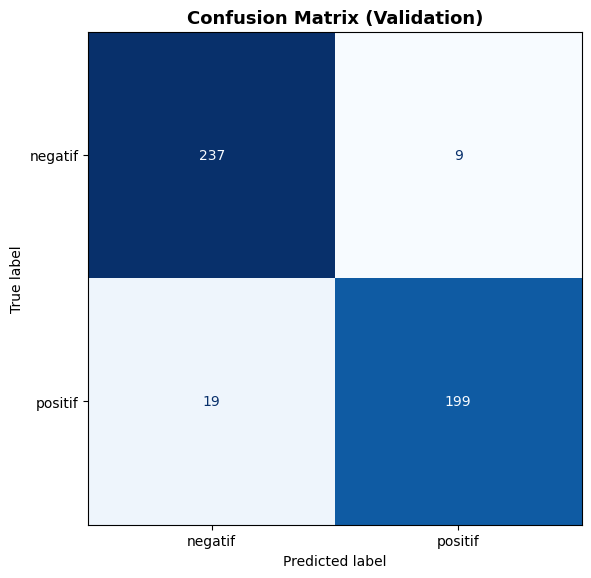

Confusion matrix saved -> /kaggle/working/evaluation_metrics/naive_bayes_confusion_matrix.png


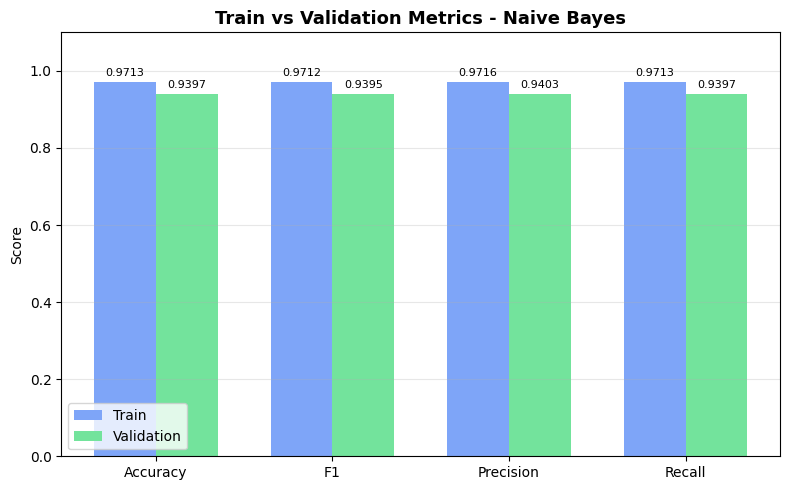

Train vs Val metrics saved -> /kaggle/working/evaluation_metrics/naive_bayes_train_vs_val_metrics.png


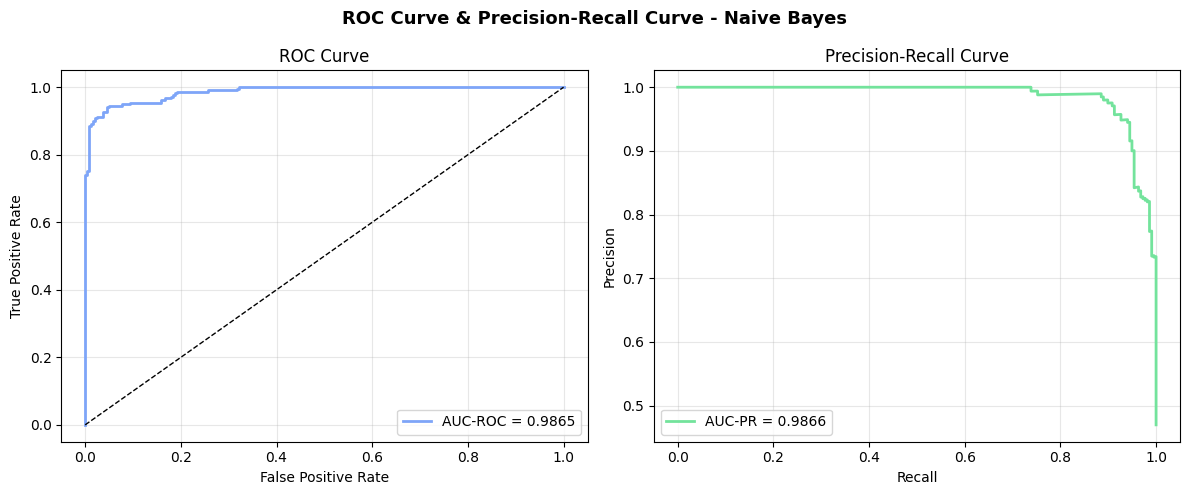

ROC & PR curves saved -> /kaggle/working/evaluation_metrics/naive_bayes_roc_pr_curves.png
All metrics saved -> /kaggle/working/evaluation_metrics/naive_bayes_all_metrics.json


In [7]:
def evaluate_nb_model(clf, tfidf, X_train_vec, y_train, X_val_vec, y_val, output_dir: str) -> dict:
    def compute_metrics(clf, X_vec, y_true):
        preds = clf.predict(X_vec)
        probs = clf.predict_proba(X_vec)[:, 1]
        labels = np.array(y_true)
        tn, fp, fn, tp = confusion_matrix(labels, preds).ravel()
        return {
            "preds" : preds,
            "probs" : probs,
            "labels": labels,
            "acc"   : accuracy_score(labels, preds),
            "f1"    : f1_score(labels, preds, average="weighted"),
            "prec"  : precision_score(labels, preds, average="weighted"),
            "rec"   : recall_score(labels, preds, average="weighted"),
            "spec"  : tn / (tn + fp) if (tn + fp) > 0 else 0.0,
            "auc_roc": roc_auc_score(labels, probs),
            "auc_pr" : average_precision_score(labels, probs),
            "cm"    : confusion_matrix(labels, preds),
        }

    tr = compute_metrics(clf, X_train_vec, y_train)
    vl = compute_metrics(clf, X_val_vec,   y_val)

    print("=" * 60)
    print("              MODEL EVALUATION RESULTS")
    print("=" * 60)
    print(f"{'Metric':<25} {'Train':>10} {'Val':>10}")
    print("-" * 60)
    for key, label in [("acc","Accuracy"),("f1","F1 (weighted)"), ("prec","Precision (weighted)"),("rec","Recall (weighted)"), ("spec","Specificity"),("auc_roc","AUC-ROC"),("auc_pr","AUC-PR")]:
        print(f"  {label:<23} {tr[key]:>10.4f} {vl[key]:>10.4f}")
    print()
    print("Validation Classification Report:")
    print(classification_report(vl["labels"], vl["preds"], target_names=["negatif","positif"], digits=4))

    fig1, ax1 = plt.subplots(figsize=(6, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=vl["cm"], display_labels=["negatif","positif"])
    disp.plot(ax=ax1, colorbar=False, cmap="Blues")
    ax1.set_title("Confusion Matrix (Validation)", fontsize=13, fontweight="bold")
    fig1.tight_layout()
    cm_path = os.path.join(output_dir, "naive_bayes_confusion_matrix.png")
    fig1.savefig(cm_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Confusion matrix saved -> {cm_path}")

    metrics_labels = ["Accuracy", "F1", "Precision", "Recall"]
    train_vals = [tr["acc"], tr["f1"], tr["prec"], tr["rec"]]
    val_vals   = [vl["acc"], vl["f1"], vl["prec"], vl["rec"]]
    x = np.arange(len(metrics_labels))
    width = 0.35
    fig2, ax2 = plt.subplots(figsize=(8, 5))
    bars1 = ax2.bar(x - width/2, train_vals, width, label="Train", color="#7ea5f8")
    bars2 = ax2.bar(x + width/2, val_vals,   width, label="Validation", color="#73e39c")
    ax2.set_ylim(0, 1.1)
    ax2.set_ylabel("Score")
    ax2.set_title("Train vs Validation Metrics - Naive Bayes", fontsize=13, fontweight="bold")
    ax2.set_xticks(x)
    ax2.set_xticklabels(metrics_labels)
    ax2.legend()
    ax2.bar_label(bars1, fmt="%.4f", padding=3, fontsize=8)
    ax2.bar_label(bars2, fmt="%.4f", padding=3, fontsize=8)
    ax2.grid(True, axis="y", alpha=0.3)
    fig2.tight_layout()
    tv_path = os.path.join(output_dir, "naive_bayes_train_vs_val_metrics.png")
    fig2.savefig(tv_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Train vs Val metrics saved -> {tv_path}")

    fpr, tpr, _ = roc_curve(vl["labels"], vl["probs"])
    prec_curve, rec_curve, _ = precision_recall_curve(vl["labels"], vl["probs"])
    fig3, (ax3, ax4) = plt.subplots(1, 2, figsize=(12, 5))
    fig3.suptitle("ROC Curve & Precision-Recall Curve - Naive Bayes", fontsize=13, fontweight="bold")
    ax3.plot(fpr, tpr, color="#7ea5f8", linewidth=2, label=f"AUC-ROC = {vl['auc_roc']:.4f}")
    ax3.plot([0, 1], [0, 1], "k--", linewidth=1)
    ax3.set_xlabel("False Positive Rate")
    ax3.set_ylabel("True Positive Rate")
    ax3.set_title("ROC Curve")
    ax3.legend(loc="lower right")
    ax3.grid(True, alpha=0.3)
    ax4.plot(rec_curve, prec_curve, color="#73e39c", linewidth=2, label=f"AUC-PR = {vl['auc_pr']:.4f}")
    ax4.set_xlabel("Recall")
    ax4.set_ylabel("Precision")
    ax4.set_title("Precision-Recall Curve")
    ax4.legend(loc="lower left")
    ax4.grid(True, alpha=0.3)
    fig3.tight_layout()
    roc_pr_path = os.path.join(output_dir, "naive_bayes_roc_pr_curves.png")
    fig3.savefig(roc_pr_path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"ROC & PR curves saved -> {roc_pr_path}")

    clf_report = classification_report(vl["labels"], vl["preds"], target_names=["negatif","positif"], output_dict=True, digits=4)
    metrics = {
        "train": {
            "accuracy"           : round(tr["acc"],  4),
            "f1_weighted"        : round(tr["f1"],   4),
            "precision_weighted" : round(tr["prec"], 4),
            "recall_weighted"    : round(tr["rec"],  4),
            "specificity"        : round(tr["spec"], 4),
            "auc_roc"            : round(tr["auc_roc"], 4),
            "auc_pr"             : round(tr["auc_pr"],  4),
            "confusion_matrix"   : tr["cm"].tolist(),
        },
        "validation": {
            "accuracy"             : round(vl["acc"],  4),
            "f1_weighted"          : round(vl["f1"],   4),
            "precision_weighted"   : round(vl["prec"], 4),
            "recall_weighted"      : round(vl["rec"],  4),
            "specificity"          : round(vl["spec"], 4),
            "auc_roc"              : round(vl["auc_roc"], 4),
            "auc_pr"               : round(vl["auc_pr"],  4),
            "confusion_matrix"     : vl["cm"].tolist(),
            "classification_report": clf_report,
        },
    }
    json_path = os.path.join(output_dir, "naive_bayes_all_metrics.json")
    with open(json_path, "w", encoding="utf-8") as f:
        json.dump(metrics, f, indent=2, ensure_ascii=False)
    print(f"All metrics saved -> {json_path}")
    return metrics

eval_metrics = evaluate_nb_model(clf, tfidf, X_train_vec, y_train, X_val_vec, y_val, EVAL_DIR)


## Phase 3 - NB-based Opinion Lexicon (IG Replacement)

In [8]:
def build_nb_lexicon(clf, tfidf, pos_threshold: float = NB_POS_THRESHOLD, neg_threshold: float = NB_NEG_THRESHOLD, top_k_display: int = 50) -> set:
    vocab        = tfidf.get_feature_names_out()
    log_prob_pos = clf.feature_log_prob_[1]
    log_prob_neg = clf.feature_log_prob_[0]
    diff         = log_prob_pos - log_prob_neg

    is_unigram = np.array([" " not in v for v in vocab])

    pos_mask   = is_unigram & (diff >= pos_threshold)
    neg_mask   = is_unigram & (diff <= neg_threshold)
    pos_tokens = vocab[pos_mask]
    neg_tokens = vocab[neg_mask]

    print(f"Positive lexicon tokens (raw): {len(pos_tokens)}")
    print(f"Negative lexicon tokens (raw): {len(neg_tokens)}")

    sorted_idx = np.argsort(diff)[::-1]
    print()
    print(f"Top NB positive tokens (diff >= {pos_threshold}):")
    print("-" * 50)
    shown = 0
    for idx in sorted_idx:
        if not is_unigram[idx]: continue
        if diff[idx] < pos_threshold: break
        print(f"  {vocab[idx]:<25} diff={diff[idx]:+.4f}")
        shown += 1
        if shown >= top_k_display: break

    print()
    print(f"Top NB negative tokens (diff <= {neg_threshold}):")
    print("-" * 50)
    shown = 0
    for idx in np.argsort(diff):
        if not is_unigram[idx]: continue
        if diff[idx] > neg_threshold: break
        print(f"  {vocab[idx]:<25} diff={diff[idx]:+.4f}")
        shown += 1
        if shown >= top_k_display: break

    lexicon = set(pos_tokens.tolist()) | set(neg_tokens.tolist())
    return lexicon

def filter_lexicon(lexicon: set) -> list:
    valid = re.compile(r"^[a-zA-Z]+$")
    return sorted([w for w in lexicon if len(w) > 2 and valid.match(w)])

NB_LEXICON = build_nb_lexicon(clf, tfidf, pos_threshold=NB_POS_THRESHOLD, neg_threshold=NB_NEG_THRESHOLD)
print(f"\nNB lexicon contains {len(NB_LEXICON)} tokens (before filter).")

filtered_lexicon = filter_lexicon(NB_LEXICON)
print(f"NB lexicon contains {len(filtered_lexicon)} tokens (after filter: no numbers/symbols, len > 2).")

lex_path = os.path.join(RESULT_DIR, "naive_bayes_lexicon.json")
with open(lex_path, "w", encoding="utf-8") as f:
    json.dump(filtered_lexicon, f, indent=2, ensure_ascii=False)
print(f"NB lexicon saved to {lex_path}")


Positive lexicon tokens (raw): 357
Negative lexicon tokens (raw): 791

Top NB positive tokens (diff >= 0.5):
--------------------------------------------------
  sukses                    diff=+2.9667
  mantap                    diff=+2.9094
  mantab                    diff=+2.7245
  keren                     diff=+2.7157
  makasih                   diff=+2.5848
  alhamdulil                diff=+2.5639
  top                       diff=+2.5245
  jangkau                   diff=+2.4362
  cepat                     diff=+2.4148
  best                      diff=+2.4037
  thank                     diff=+2.3933
  ramah                     diff=+2.3895
  adem                      diff=+2.3867
  terimakasih               diff=+2.3776
  cantik                    diff=+2.2852
  aman                      diff=+2.2515
  mantaap                   diff=+2.2463
  fast                      diff=+2.2299
  selalu                    diff=+2.2218
  you                       diff=+2.1962
  thanks            

## Phase 4 - Parsing

#### Clause Splitting on Conjunctions and Punctuation

In [9]:
def split_into_clauses(text: str) -> list[str]:
    conj_pattern = r"\b(" + "|".join(SPLIT_CONJUNCTIONS) + r")\b"
    parts        = re.split(conj_pattern, text)
    clauses = []
    for part in parts:
        if part.strip() in SPLIT_CONJUNCTIONS:
            continue
        sub_parts = re.split(r"[,;.!?]", part)
        clauses.extend(sub_parts)
    return [c.strip() for c in clauses if len(c.strip().split()) >= 2]

sample = "pengiriman cepat tapi produk jelek,, packing rapi dan admin ramah .. ."
print("Clause splitting example")
print(f"INPUT  : {sample}")
print(f"OUTPUT : {split_into_clauses(sample)}")


Clause splitting example
INPUT  : pengiriman cepat tapi produk jelek,, packing rapi dan admin ramah .. .
OUTPUT : ['pengiriman cepat', 'produk jelek', 'packing rapi', 'admin ramah']


#### POS & Dependency Parsing + Phrase Extraction (Stanza)

In [10]:
def pos_and_dep_parse(text: str) -> list[dict]:
    doc    = nlp_stanza(text)
    tokens = []
    for sent in doc.sentences:
        for word in sent.words:
            tokens.append({
                "id"     : word.id - 1,
                "word"   : word.lemma.lower() if word.lemma else word.text.lower(),
                "pos"    : word.upos,
                "dep"    : word.deprel,
                "head_id": word.head - 1,
            })
    return tokens

def extract_phrases(clause: str) -> list[dict]:
    tokens = pos_and_dep_parse(clause)
    if not tokens:
        return []

    phrases  = []
    seen     = set()
    n        = len(tokens)
    NOUN_POS = {"NOUN", "PROPN"}
    ADJ_POS  = {"ADJ"}
    ADV_POS  = {"ADV"}
    VERB_POS = {"VERB"}

    def is_neg(tok):
        return tok["word"] in NEGATION_WORDS

    def add(tokens_in_phrase, pattern):
        text = " ".join(t["word"] for t in tokens_in_phrase)
        if text not in seen:
            seen.add(text)
            phrases.append({"phrase": text, "pattern": pattern})

    # Rule 1
    for i in range(n - 1):
        if tokens[i]["pos"] in NOUN_POS and tokens[i+1]["pos"] in ADJ_POS:
            if not is_neg(tokens[i]) and not is_neg(tokens[i+1]):
                add([tokens[i], tokens[i+1]], "R1_NOUN+ADJ")
    # Rule 2
    for i in range(n - 2):
        if (tokens[i]["pos"] in NOUN_POS and tokens[i+1]["pos"] in ADV_POS and tokens[i+2]["pos"] in ADJ_POS and not is_neg(tokens[i+1])):
            add([tokens[i], tokens[i+1], tokens[i+2]], "R2_NOUN+ADV+ADJ")
    # Rule 3
    for i in range(n - 2):
        if (tokens[i]["pos"] in NOUN_POS and is_neg(tokens[i+1]) and tokens[i+2]["pos"] in ADJ_POS):
            add([tokens[i], tokens[i+1], tokens[i+2]], "R3_NOUN+NEG+ADJ")
    # Rule 4
    for i in range(n - 3):
        if (tokens[i]["pos"] in NOUN_POS and is_neg(tokens[i+1]) and tokens[i+2]["pos"] in ADV_POS and tokens[i+3]["pos"] in ADJ_POS):
            add([tokens[i], tokens[i+1], tokens[i+2], tokens[i+3]], "R4_NOUN+NEG+ADV+ADJ")
    # Rule 5
    for i in range(n - 1):
        if tokens[i]["pos"] in ADJ_POS and tokens[i+1]["pos"] in NOUN_POS:
            if tokens[i+1]["dep"] in {"root", "nsubj"}:
                add([tokens[i+1], tokens[i]], "R5_ADJ+NOUN")
    # Rule 6
    for i in range(n - 2):
        if (tokens[i]["pos"] in NOUN_POS and tokens[i+1]["pos"] in VERB_POS and tokens[i+2]["pos"] in ADJ_POS):
            add([tokens[i], tokens[i+1], tokens[i+2]], "R6_NOUN+VERB+ADJ")
    # Rule 7
    for i in range(n - 3):
        if (tokens[i]["pos"] in NOUN_POS and tokens[i+1]["pos"] in VERB_POS and is_neg(tokens[i+2]) and tokens[i+3]["pos"] in ADJ_POS):
            add([tokens[i], tokens[i+1], tokens[i+2], tokens[i+3]], "R7_NOUN+VERB+NEG+ADJ")
    # Rule 8
    for i in range(n - 2):
        if (tokens[i]["pos"] in NOUN_POS and tokens[i+1]["pos"] in NOUN_POS and tokens[i+2]["pos"] in ADJ_POS):
            add([tokens[i], tokens[i+1], tokens[i+2]], "R8_NOUN+NOUN+ADJ")
    # Rule 9
    for i in range(n - 3):
        if (tokens[i]["pos"] in NOUN_POS and tokens[i+1]["pos"] in NOUN_POS and is_neg(tokens[i+2]) and tokens[i+3]["pos"] in ADJ_POS):
            add([tokens[i], tokens[i+1], tokens[i+2], tokens[i+3]], "R9_NOUN+NOUN+NEG+ADJ")
    # Rule 10
    for i in range(n - 2):
        if (tokens[i]["pos"] in NOUN_POS and tokens[i+1]["pos"] in ADJ_POS and tokens[i+2]["pos"] in ADJ_POS):
            add([tokens[i], tokens[i+1], tokens[i+2]], "R10_NOUN+ADJ+ADJ")
    # Rule 11
    for token in tokens:
        if token["dep"] == "conj":
            head_id = token["head_id"]
            if 0 <= head_id < n:
                head = tokens[head_id]
                if head["pos"] in NOUN_POS and token["pos"] in ADJ_POS:
                    add([head, token], "R11_conj+shared_head")
                elif head["pos"] in ADJ_POS and token["pos"] in ADJ_POS:
                    for other in tokens:
                        if other["pos"] in NOUN_POS and other["head_id"] == head_id:
                            add([other, head, token], "R11_conj+shared_head")
                            break

    return phrases

test_clause = "pengiriman sangat cepat"
print("POS + Dependency parse:")
for t in pos_and_dep_parse(test_clause):
    print(f"  {t['word']:15} POS={t['pos']:6} DEP={t['dep']}")
print("\nPhrase extraction:")
for p in extract_phrases(test_clause):
    print(f"  {p}")


POS + Dependency parse:
  pengiriman      POS=NOUN   DEP=root
  sangat          POS=ADV    DEP=advmod
  cepat           POS=ADJ    DEP=amod

Phrase extraction:
  {'phrase': 'pengiriman sangat cepat', 'pattern': 'R2_NOUN+ADV+ADJ'}


## Phase 5 - NB Lexicon Filter

In [11]:
def filter_by_nb_lexicon(phrase_list: list[dict]) -> list[dict]:
    if not NB_LEXICON:
        print("Warning: NB_LEXICON is empty. Skipping lexicon filter.")
        return phrase_list
    return [p for p in phrase_list if any(w in NB_LEXICON for w in p["phrase"].lower().split())]

## Phase 6 - Phrase Sentiment Prediction

In [12]:
def predict_sentiment_nb_batch(texts: list[str]) -> list[dict]:
    vecs  = tfidf.transform(texts)
    probs = clf.predict_proba(vecs)
    results = []
    for prob in probs:
        label_id = int(np.argmax(prob))
        results.append({
            "label": ID2LABEL[label_id],
            "score": float(prob[label_id]),
        })
    return results

def predict_phrases_sentiment(phrase_list: list[dict]) -> list[dict]:
    if not phrase_list:
        return []
    texts       = [p["phrase"] for p in phrase_list]
    predictions = predict_sentiment_nb_batch(texts)
    return [
        {
            "phrase"   : pd_item["phrase"],
            "sentiment": pred["label"],
            "score"    : pred["score"],
            "pattern"  : pd_item["pattern"],
        }
        for pd_item, pred in zip(phrase_list, predictions)
        # if pred["score"] >= CONFIDENCE_THRESHOLD
    ]


## Phase 7 - Semantic Deduplication (TF-IDF cosine similarity)

In [13]:
def get_phrase_embeddings_nb(phrases: list[str]) -> np.ndarray:
    vecs = tfidf.transform(phrases)
    return vecs.toarray()

def semantic_deduplication(phrase_sentiment_list: list[dict], threshold: float = SIMILARITY_THRESHOLD) -> list[dict]:
    if not phrase_sentiment_list: return []
    def cluster_phrases(phrases):
        if not phrases: return []
        texts          = [p["phrase"] for p in phrases]
        freq           = Counter(texts)
        unique_phrases = list(freq.keys())
        unique_counts  = [freq[p] for p in unique_phrases]

        if len(unique_phrases) <= 1:
            return [{"phrase": unique_phrases[0], "count": unique_counts[0]}] if unique_phrases else []

        embeddings = get_phrase_embeddings_nb(unique_phrases)
        sim_matrix = cosine_similarity(embeddings)
        merged = [False] * len(unique_phrases)
        result = []
        for i in range(len(unique_phrases)):
            if merged[i]: continue
            cluster_count = unique_counts[i]
            for j in range(i + 1, len(unique_phrases)):
                if not merged[j] and sim_matrix[i][j] >= threshold:
                    cluster_count += unique_counts[j]
                    merged[j]      = True
            result.append({"phrase": unique_phrases[i], "count": cluster_count})
        return result

    print("Running semantic deduplication...")
    pos_clustered = cluster_phrases([p for p in phrase_sentiment_list if p["sentiment"] == "positif"])
    neg_clustered = cluster_phrases([p for p in phrase_sentiment_list if p["sentiment"] == "negatif"])

    final = (
        [{**item, "sentiment": "positif"} for item in pos_clustered] +
        [{**item, "sentiment": "negatif"} for item in neg_clustered]
    )
    return final


## Phase 8 - Full Pipeline

In [14]:
def run_full_pipeline(df: pd.DataFrame, top_n: int = TOP_N_SUMMARY, min_count: int = MIN_COUNT):
    all_phrases = []
    total       = len(df)
    start       = time.time()

    print(f"Processing {total} reviews...\n")
    with tqdm(total=total, desc="Phrase Extraction", unit="review") as pbar:
        for i, (_, row) in enumerate(df.iterrows()):
            review  = row["review_normalized"]
            clauses = split_into_clauses(review) or [review]
            for clause in clauses:
                all_phrases.extend(extract_phrases(clause))
            pbar.update(1)
            if i % 10 == 0:
                elapsed = time.time() - start
                rate    = (i + 1) / elapsed if elapsed > 0 else 0
                eta     = (total - i) / rate if rate > 0 else 0
                pbar.set_postfix({
                    "phrases": len(all_phrases),
                    "rate"   : f"{rate:.1f} rev/s",
                    "ETA"    : f"{int(eta//60)}m {int(eta%60):02d}s",
                })

    print()
    print(f"Extraction complete in {int((time.time()-start)//60)}m {int((time.time()-start)%60):02d}s")
    print(f"Total phrases extracted: {len(all_phrases)}")

    if not all_phrases:
        print("No phrases extracted.")
        return None, None, {"total_extracted": 0, "total_accepted": 0, "total_rejected": 0}

    all_phrases = filter_by_nb_lexicon(all_phrases)
    print(f"Phrases after NB filter: {len(all_phrases)}")

    print()
    print("Predicting phrase sentiment...")
    accepted = []
    with tqdm(total=len(all_phrases), desc="Sentiment Prediction", unit="phrase") as pbar2:
        for i in range(0, len(all_phrases), 64):
            batch  = all_phrases[i : i + 64]
            result = predict_phrases_sentiment(batch)
            accepted.extend(result)
            pbar2.update(len(batch))
            pbar2.set_postfix({
                "accepted": len(accepted),
                "rejected": (i + len(batch)) - len(accepted),
            })

    total_accepted = len(accepted)
    total_rejected = len(all_phrases) - total_accepted

    print()
    print(f"Phrases accepted: {total_accepted}")
    print(f"Phrases rejected: {total_rejected} (confidence < {CONFIDENCE_THRESHOLD})")

    phrase_stats = {
        "total_extracted": len(all_phrases),
        "total_accepted" : total_accepted,
        "total_rejected" : total_rejected,
    }

    deduplicated = semantic_deduplication(accepted)
    pos_raw = sorted([p for p in deduplicated if p["sentiment"] == "positif"], key=lambda x: x["count"], reverse=True)
    neg_raw = sorted([p for p in deduplicated if p["sentiment"] == "negatif"], key=lambda x: x["count"], reverse=True)

    print(f"Unique positive clusters: {len(pos_raw)}")
    print(f"Unique negative clusters: {len(neg_raw)}")

    for p in pos_raw + neg_raw:
        p["pct"] = round(min(p["count"] / total * 100, 100.0), 1)

    pos_phrases = [p for p in pos_raw[:top_n] if p["count"] >= min_count]
    neg_phrases = [p for p in neg_raw[:top_n] if p["count"] >= min_count]

    elapsed_total = time.time() - start
    print()
    print(f"Pipeline complete in {int(elapsed_total//60)}m {int(elapsed_total%60):02d}s")

    return pos_phrases, neg_phrases, phrase_stats

df_sample = df_raw.reset_index(drop=True)
pos_summary, neg_summary, phrase_stats = run_full_pipeline(df_sample, top_n=TOP_N_SUMMARY, min_count=MIN_COUNT)

if pos_summary and neg_summary:
    print("\n" + "=" * 55)
    print("          AUTOMATED REVIEW SUMMARY")
    print("=" * 55)

    print("\nPOSITIVE SUMMARY")
    print("-" * 55)
    for i, p in enumerate(pos_summary, 1):
        bar = "#" * max(1, int(p["pct"] / 2))
        print(f"  {i:2}. {p['phrase']:<25} {bar:<20} {p['pct']}% ({p['count']} occurrences)")

    print("\nNEGATIVE SUMMARY")
    print("-" * 55)
    for i, p in enumerate(neg_summary, 1):
        bar = "#" * max(1, int(p["pct"] / 2))
        print(f"  {i:2}. {p['phrase']:<25} {bar:<20} {p['pct']}% ({p['count']} occurrences)")

    print("\n" + "=" * 55)


Processing 4638 reviews...



Phrase Extraction:   0%|          | 0/4638 [00:00<?, ?review/s]


Extraction complete in 34m 05s
Total phrases extracted: 5841
Phrases after NB filter: 5289

Predicting phrase sentiment...


Sentiment Prediction:   0%|          | 0/5289 [00:00<?, ?phrase/s]


Phrases accepted: 5289
Phrases rejected: 0 (confidence < 0.75)
Running semantic deduplication...
Unique positive clusters: 967
Unique negative clusters: 1527

Pipeline complete in 34m 06s

          AUTOMATED REVIEW SUMMARY

POSITIVE SUMMARY
-------------------------------------------------------
   1. pengiriman cepat          ##                   5.5% (254 occurrences)
   2. packaging aman            #                    2.7% (123 occurrences)
   3. packaging rapi            #                    2.0% (95 occurrences)
   4. barang bagus              #                    1.8% (82 occurrences)
   5. pesan cepat               #                    1.5% (68 occurrences)
   6. produk bagus              #                    1.4% (63 occurrences)
   7. proses pesan cepat        #                    1.4% (63 occurrences)
   8. respon cepat              #                    1.1% (49 occurrences)
   9. produk sesuai             #                    1.0% (45 occurrences)
  10. harga murah       

## Phase 9 - Save All Outputs

In [15]:
def save_phrase_summary(pos_phrases, neg_phrases, phrase_stats: dict, output_dir: str) -> None:
    summary = {
        "phrase_stats": phrase_stats,
        "positive"    : pos_phrases or [],
        "negative"    : neg_phrases or [],
    }
    path = os.path.join(output_dir, "naive_bayes_phrase_summary.json")
    with open(path, "w", encoding="utf-8") as f:
        json.dump(summary, f, indent=2, ensure_ascii=False)
    print(f"Phrase summary saved to {path}")

save_phrase_summary(pos_summary, neg_summary, phrase_stats, RESULT_DIR)

print("\nAll outputs")
for subdir in [MODEL_DIR, EVAL_DIR, RESULT_DIR]:
    for fname in sorted(os.listdir(subdir)):
        fpath = os.path.join(subdir, fname)
        if os.path.isfile(fpath):
            size_kb = os.path.getsize(fpath) / 1024
            print(f"  {fname:<55} {size_kb:>8.1f} KB")


Phrase summary saved to /kaggle/working/results/naive_bayes_phrase_summary.json


## Phase 10 - Analyze Single Review

In [16]:
def analyze_single_review(review_text: str) -> list[dict]:
    print(f"Review    : {review_text}")
    print()
    normalized = normalize_text(review_text)
    print(f"Normalized: {normalized}")
    clauses = split_into_clauses(normalized)
    print(f"Clauses   : {clauses}")
    print()

    all_accepted = []
    for clause in clauses:
        print(f"Clause: '{clause}'")
        tokens = pos_and_dep_parse(clause)
        print(f"Tokens: {[(t['word'], t['pos'], t['dep']) for t in tokens]}")
        phrases = extract_phrases(clause)
        print(f"Phrases extracted  : {[p['phrase'] for p in phrases]}")
        phrases = filter_by_nb_lexicon(phrases)
        print(f"After NB filter    : {[p['phrase'] for p in phrases]}")

        if phrases:
            accepted = predict_phrases_sentiment(phrases)
            print()
            print("Predictions:")
            for a in accepted:
                print(f"'{a['phrase']}' = {a['sentiment'].upper()} (score={a['score']:.2f})")
            all_accepted.extend(accepted)
        print()
    return all_accepted


In [17]:
analyze_single_review("barang tidak bagus")

Review    : barang tidak bagus

Normalized: barang tidak bagus
Clauses   : ['barang tidak bagus']

Clause: 'barang tidak bagus'
Tokens: [('barang', 'NOUN', 'root'), ('tidak', 'PART', 'advmod'), ('bagus', 'ADJ', 'amod')]
Phrases extracted  : ['barang tidak bagus']
After NB filter    : ['barang tidak bagus']

Predictions:
'barang tidak bagus' = NEGATIF (score=0.93)



[{'phrase': 'barang tidak bagus',
  'sentiment': 'negatif',
  'score': 0.933801398506246,
  'pattern': 'R3_NOUN+NEG+ADJ'}]